# Custome Model - Huấn luyện mô hình tùy chỉnh

---

Mục tiêu là sủ dụng tham số đã tối ưu trước đó huấn luyện mô hình tùy chỉnh với số lượng epochs lớn và là điểm khởi đầu để so sánh với các model phía sau.

In [1]:
import os
import sys
import numpy as np
from math import ceil
from pathlib import Path

import tensorflow as tf
from keras.models import load_model
from keras.optimizers import AdamW
from keras.optimizers.schedules import CosineDecay
from keras.losses import BinaryFocalCrossentropy
from keras.utils import set_random_seed
from keras.callbacks import ModelCheckpoint
from sklearn.metrics import classification_report

sys.path.append(os.path.abspath('..'))
from models.CustomModel import custom_model
from src.data import build_balanced_train_ds, build_eval_ds, clear_cache
from src.evaluate import MetricsCallback, plot_training_history, evaluate_model, calculate_metrics

I0000 00:00:1791601897.342821 1036575 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791601897.930633 1036575 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791601902.273426 1036575 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
IMG_SIZE = 224
EPOCHS = 30
BATCH_SIZE = 32
SEED = 42
OUTPUT_DIR = '../outputs/custom-model'
CACHE = '../cache/custom-model'

set_random_seed(SEED)

# Xóa cache cũ để tránh lỗi (nếu có)
import shutil
if os.path.exists(CACHE):
    shutil.rmtree(CACHE)
os.makedirs(CACHE, exist_ok=True)
clear_cache(CACHE)

## 1. Chuẩn bị dữ liệu

---

In [3]:
train_dir = '../datasets/LCC_FASD/train'
val_dir   = '../datasets/LCC_FASD/val'
test_dir  = '../datasets/LCC_FASD/test'

train_ds = build_balanced_train_ds(train_dir, IMG_SIZE, BATCH_SIZE, cache_dir=CACHE, seed=SEED)
val_ds   = build_eval_ds(val_dir,  IMG_SIZE, BATCH_SIZE, 'val',  cache_dir=CACHE)
test_ds  = build_eval_ds(test_dir, IMG_SIZE, BATCH_SIZE, 'test', cache_dir=CACHE)

x, y = next(iter(train_ds))
print(x.shape, float(tf.reduce_min(x)), float(tf.reduce_max(x)), int(tf.reduce_sum(y)))

Train: 1223 real | 7076 spoof | mỗi batch 16 real + 16 spoof


E0000 00:00:1791601907.153078 1036575 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


val: 2948 ảnh
test: 7580 ảnh


W0000 00:00:1791601911.212313 1036824 cache_dataset_ops.cc:330] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


(32, 224, 224, 3) 0.0 1.0 16


W0000 00:00:1791601915.741403 1036575 cache_dataset_ops.cc:330] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


## 2. Khởi tạo mô hình

---

Mô hình được xây dựng trong [CustomeModel](../models/CustomeModel.py)

In [4]:
input_shape = (IMG_SIZE, IMG_SIZE, 3)

model = custom_model(input_shape=input_shape, num_classes=1)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 112, 112, 16)   │           432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 112, 112, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 112, 112, 32)   │           656 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 56, 56, 64)     │         2,336 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_2              │ (None, 28, 28, 128)    │         8,768 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_3              │ (None, 14, 14, 256)    │        33,920 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             

 Total params: 64,609 (252.38 KB)

 Trainable params: 63,617 (248.50 KB)

 Non-trainable params: 992 (3.88 KB)

In [5]:
metrics_callback = MetricsCallback(val_dataset=val_ds, threshold_path=OUTPUT_DIR + '/best_threshold.txt')

callbacks = [
    metrics_callback,

    ModelCheckpoint(
        filepath=OUTPUT_DIR + '/best_model.keras', 
        monitor='val_acer', 
        save_best_only=True, 
        mode='min', 
        verbose=1
    )
]

num_train = sum(1 for p in Path(train_dir).rglob('*.png') if p.is_file())
steps_per_epoch = ceil(num_train / BATCH_SIZE)

lr_schedule = CosineDecay(
    initial_learning_rate=0.000363,
    decay_steps=EPOCHS * steps_per_epoch
)

model.compile(
    optimizer=AdamW(learning_rate=lr_schedule, weight_decay=2e-3),
    loss=BinaryFocalCrossentropy(gamma=2.0),
    metrics=['accuracy']
)

W0000 00:00:1791601920.803612 1036575 cache_dataset_ops.cc:330] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


## 3. Huấn luyện mô hình

In [6]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    steps_per_epoch=steps_per_epoch,
    shuffle=False
)

Epoch 1/30
260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.7487 - loss: 0.1304 - APCER: 28.27% - BPCER: 28.15% - EER: 28.21% - ACER: 28.21% (t*: 0.5434) ⭐ NEW BEST

Epoch 1: val_acer improved from None to 0.28211, saving model to ../outputs/custom-model/best_model.keras

Epoch 1: finished saving model to ../outputs/custom-model/best_model.keras
260/260 ━━━━━━━━━━━━━━━━━━━━ 124s 435ms/step - accuracy: 0.7487 - loss: 0.1304 - val_accuracy: 0.8626 - val_loss: 0.1413 - val_apcer: 0.2827 - val_bpcer: 0.2815 - val_eer: 0.2821 - val_acer: 0.2821
Epoch 2/30
 25/260 ━━━━━━━━━━━━━━━━━━━━ 1:20 344ms/step - accuracy: 0.8050 - loss: 0.1118

W0000 00:00:1791602053.349516 1037002 cache_dataset_ops.cc:330] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.8314 - loss: 0.0994 - APCER: 20.96% - BPCER: 20.99% - EER: 20.97% - ACER: 20.97% (t*: 0.6176) ⭐ NEW BEST

Epoch 2: val_acer improved from 0.28211 to 0.20974, saving model to ../outputs/custom-model/best_model.keras

Epoch 2: finished saving model to ../outputs/custom-model/best_model.keras
260/260 ━━━━━━━━━━━━━━━━━━━━ 92s 354ms/step - accuracy: 0.8314 - loss: 0.0994 - val_accuracy: 0.8735 - val_loss: 0.0888 - val_apcer: 0.2096 - val_bpcer: 0.2099 - val_eer: 0.2097 - val_acer: 0.2097
Epoch 3/30
260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.8481 - loss: 0.0910 - APCER: 18.01% - BPCER: 18.02% - EER: 18.02% - ACER: 18.02% (t*: 0.3725) ⭐ NEW BEST

Epoch 3: val_acer improved from 0.20974 to 0.18017, saving model to ../outputs/custom-model/best_model.keras

Epoch 3: finished saving model to ../outputs/custom-model/best_model.keras
260/260 ━━━━━━━━━━━━━━━━━━━━ 101s 391ms/step - accuracy: 0.8481 - loss: 0.0910 - val_accuracy: 0

# 4. Đánh giá kết quả 

---

In [7]:
model = load_model(OUTPUT_DIR + '/best_model.keras', compile=False)
threshold_best = float(open(OUTPUT_DIR + '/best_threshold.txt').read())
print(f"Ngưỡng tốt nhất: {threshold_best}")

y_prob = model.predict(test_ds)
y_pred = (y_prob >= threshold_best).astype(int).flatten()

y_true = np.concatenate([y.numpy() if hasattr(y, 'numpy') else y for x, y in test_ds], axis=0).flatten()

print(classification_report(y_true, y_pred))

Ngưỡng tốt nhất: 0.28395551443099976
237/237 ━━━━━━━━━━━━━━━━━━━━ 30s 122ms/step


W0000 00:00:1791605010.280561 1036575 cache_dataset_ops.cc:330] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


              precision    recall  f1-score   support

         0.0       0.31      0.80      0.45       314
         1.0       0.99      0.92      0.96      7266

    accuracy                           0.92      7580
   macro avg       0.65      0.86      0.70      7580
weighted avg       0.96      0.92      0.93      7580



Đã lưu biểu đồ lịch sử tại: ../outputs/custom-model/training_history.png


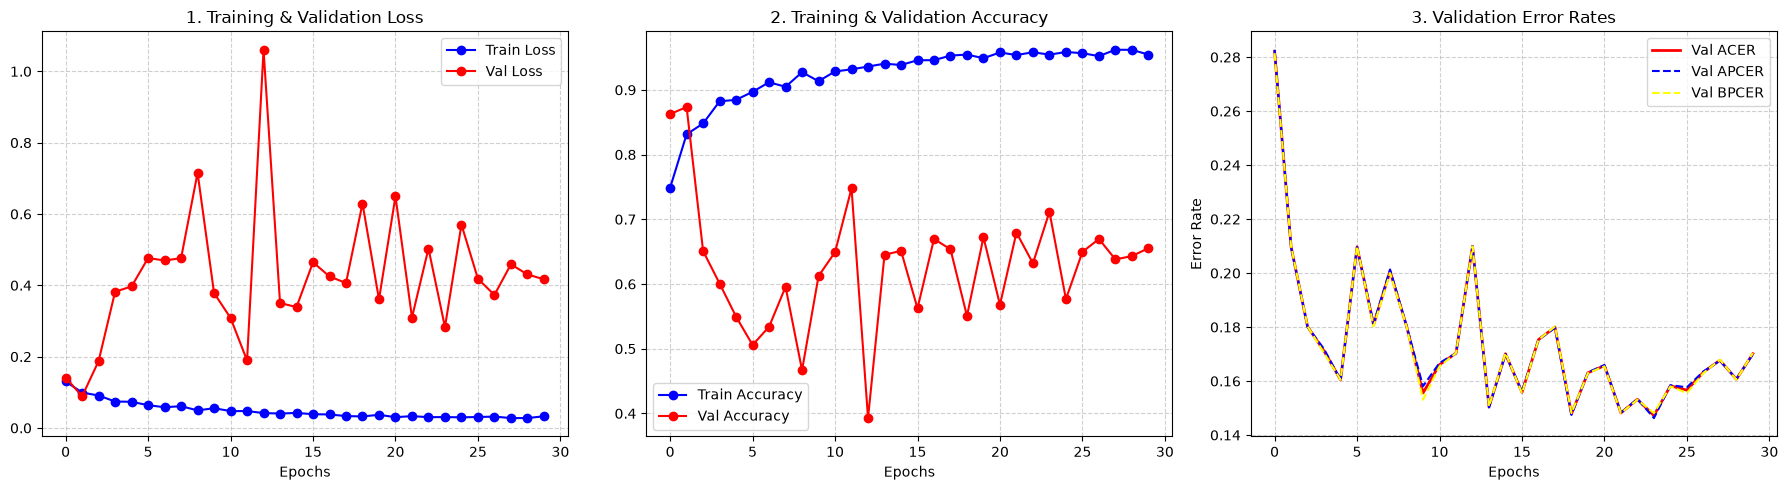

In [8]:
plot_training_history(history.history, output=OUTPUT_DIR + '/training_history.png')

In [9]:
y_val_prob = model.predict(val_ds)
y_val_true = np.concatenate([y.numpy() if hasattr(y, 'numpy') else y for x, y in val_ds], axis=0).flatten()

93/93 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step


Đã lưu biểu đồ tại: ../outputs/custom-model/evaluation_report.png


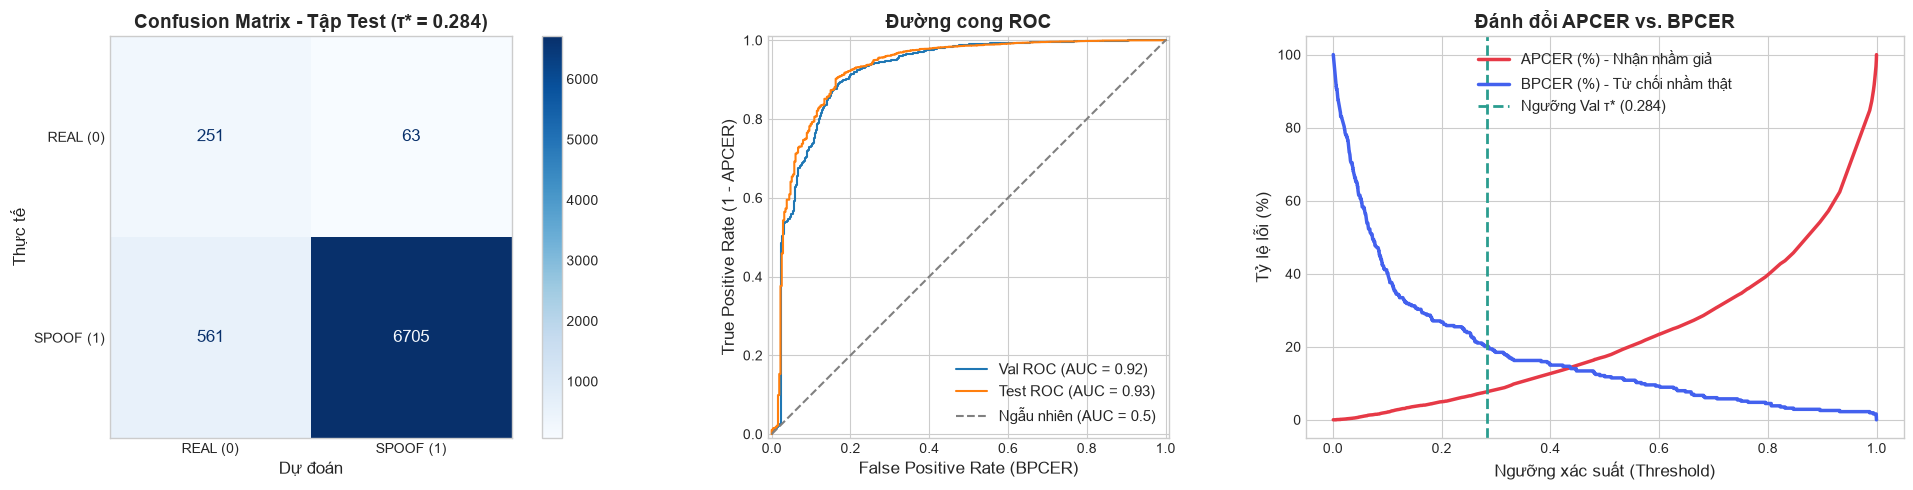

In [10]:
y_test = (y_true, y_prob)
y_val = (y_val_true, y_val_prob)

evaluate_model(y_test, y_val, threshold_best, output=OUTPUT_DIR + '/evaluation_report.png')

In [11]:
metrics = calculate_metrics(y_true, y_prob, threshold_best)

print("Metrics on test set:")
for metric_name, metric_value in metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")

Metrics on test set:
EER (%): 14.3312
APCER (%): 7.7209
BPCER (%): 20.0637
ACER (%): 13.8923
AUC (%): 92.6928
ACC (%): 91.7678
